**Task 1) Analyze the dataset: ans.csv**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv('data/ans.csv')

all_x = pd.concat([df['x1'], df['x2'], df['x3'], df['x4']])
all_y = pd.concat([df['y1'], df['y2'], df['y3'], df['y4']])

# Function to compute accuracy (standard deviation of subset statistics)
def compute_accuracy(stat_func):
    subset_stats = []
    for i in range(1, 5):
        x = df[f'x{i}']
        y = df[f'y{i}']
        subset_stats.append(stat_func(x, y))
    return np.std(subset_stats)

# Calculate mean and variance
mean_x =np.mean(all_x)
var_x = np.mean([np.var(df[f'x{i}'], ddof=1) for i in range(1, 5)]) # ddof=1 - sample variance

mean_y = np.mean(all_y)
var_y = np.mean([np.var(df[f'y{i}'], ddof=1) for i in range(1, 5)]) # ddof=1 - sample variance

# Calculate correlation between x and y
corr, _ = stats.pearsonr(all_x, all_y)

# Calculate linear regression line
slope, intercept, r_value, _, _ = stats.linregress(all_x, all_y)
regression_line = f"y = {intercept:.2f} + {slope:.3f}x"
r_squared = r_value**2

# Accuracy
accuracy_mean_x = compute_accuracy(lambda x, y: np.mean(x))
accuracy_var_x = compute_accuracy(lambda x, y: np.var(x, ddof=1))
accuracy_mean_y = compute_accuracy(lambda x, y: np.mean(y))
accuracy_var_y = compute_accuracy(lambda x, y: np.var(y, ddof=1))
accuracy_corr = compute_accuracy(lambda x, y: stats.pearsonr(x, y)[0])
accuracy_r_squared = compute_accuracy(lambda x, y: stats.linregress(x, y)[2]**2)

df_results = pd.DataFrame({
    'Property': [
    'Mean of x',
    'Sample variance of x',
    'Mean of y',
    'Sample variance of y',
    'Correlation between x and y',
    'Linear regression line (y = a+bx)',
    'Coefficient of determination of the linear regression'
    ],

    'Value': [
    f'{mean_x}',
    f'{var_x}',
    f'{mean_y:.2f}',
    f'{var_y:.3f}',
    f'{corr:.3f}',
    regression_line,
    f'{r_squared:.2f}'
    ],

    'Accuracy': [
    f"{accuracy_mean_x}",
    f"{accuracy_var_x}",
    f"{accuracy_mean_y:.2f}",
    f"{accuracy_var_y:.3f}",
    f"{accuracy_corr:.3f}",
    "None",  # Regression line is identical in Anscombe's Quartet
    f"{accuracy_r_squared:.2f}"
    ]
})
print(df_results)

                                            Property              Value  \
0                                          Mean of x                9.0   
1                               Sample variance of x               11.0   
2                                          Mean of y               7.50   
3                               Sample variance of y              4.125   
4                        Correlation between x and y              0.816   
5                  Linear regression line (y = a+bx)  y = 3.00 + 0.500x   
6  Coefficient of determination of the linear reg...               0.67   

  Accuracy  
0      0.0  
1      0.0  
2     0.00  
3    0.002  
4    0.000  
5     None  
6     0.00  


**Scatter plot for Task 1**

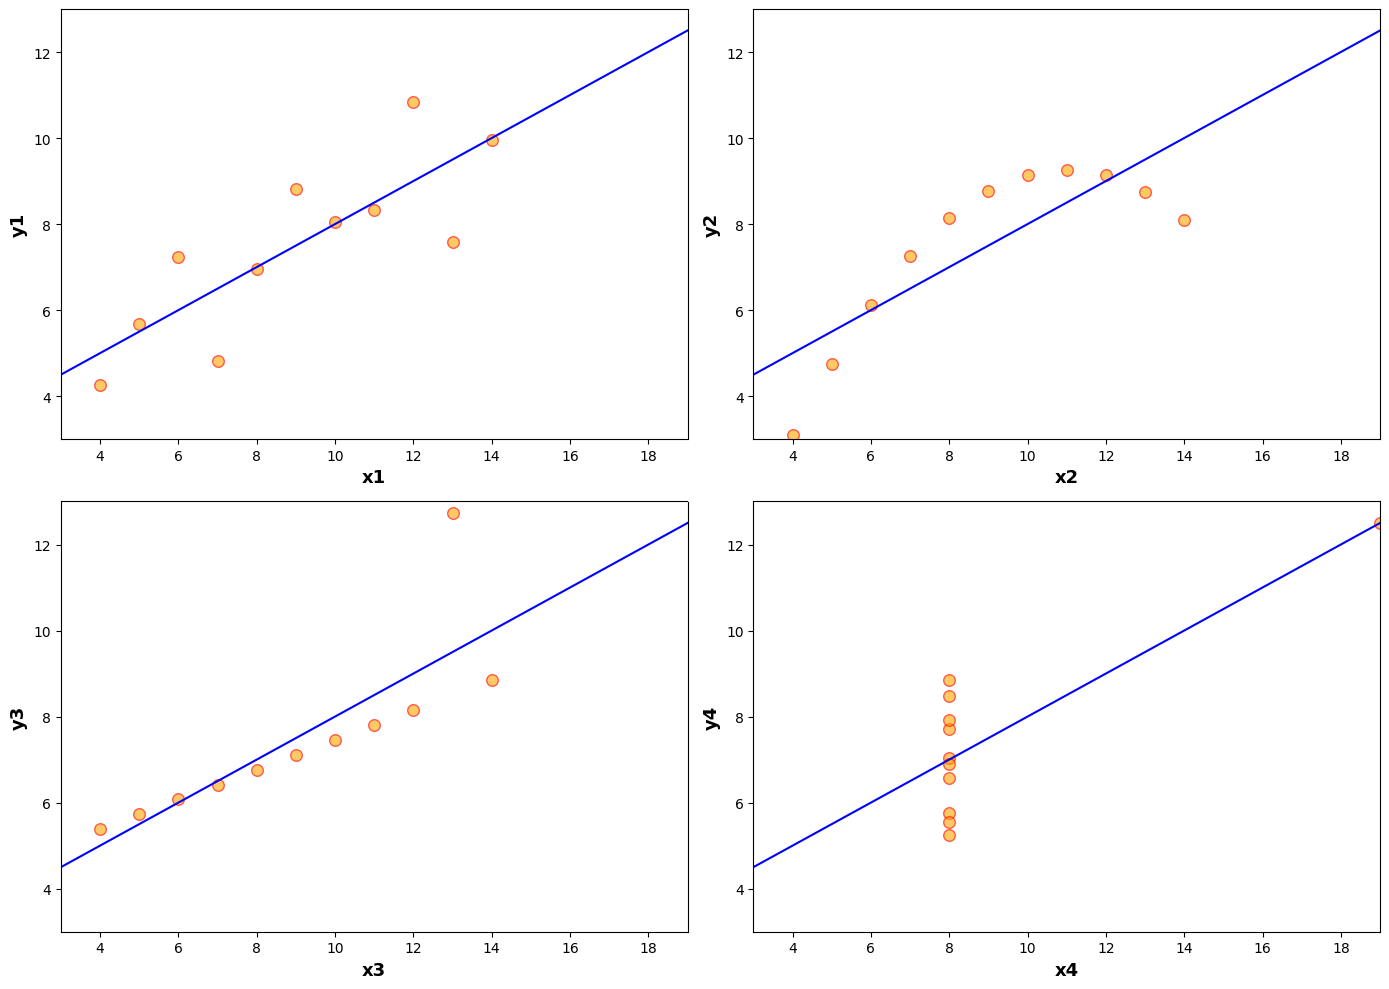

In [3]:
fig, axs = plt.subplots(2, 2,  figsize=(14,10))

# Common regression line 
slope, intercept, _, _, _ = stats.linregress(
    pd.concat([df['x1'], df['x2'], df['x3'], df['x4']]),
    pd.concat([df['y1'], df['y2'], df['y3'], df['y4']])
)

# Plot each dataset
for i, ax in enumerate(axs.flat, start=1):
    x = df[f'x{i}']
    y = df[f'y{i}']
    
    # Scatter plot
    ax.scatter(x, y, color='orange', alpha=0.6, edgecolor='red', s=70)
    
    # Regression line 
    x_range = np.linspace(3, 19)
    ax.plot(x_range, intercept + slope * x_range, 'b-')
    
    # Subplot labels and limits
    ax.set_xlabel(f'x{i}', fontsize=13, fontweight= 'bold')
    ax.set_ylabel(f'y{i}', fontsize=13, fontweight= 'bold')
    
    ax.set_xlim(3, 19)
    ax.set_ylim(3, 13)
    
plt.tight_layout()
plt.show()

plt.show()

**Task 2) Analyze the dataset: ans2.tsv**

In [4]:
df = pd.read_csv('data/ans2.tsv', sep='\t')

x = df['x']
y = df['y']

# Calculate mean and standard deviation
mean_x =  np.mean(x)
sd_x = np.std(x)

mean_y = np.mean(y)
sd_y = np.std(y)

# Calculate correlation between x and y
corr, _ = stats.pearsonr(x, y)

datasets = df['dataset'].unique()

# Function to compute accuracy (standard deviation of subset statistics)
def compute_accuracy(stat_func):
    subset_stats = []
    for dataset in datasets:
        subset = df[df['dataset'] == dataset]
        x_sub = subset['x']
        y_sub = subset['y']
        subset_stats.append(stat_func(x_sub, y_sub))
    return np.std(subset_stats)

# Accuracy
accuracy_mean_x = compute_accuracy(lambda x, y: np.mean(x))
accuracy_sd_x = compute_accuracy(lambda x, y: np.std(x))
accuracy_mean_y = compute_accuracy(lambda x, y: np.mean(y))
accuracy_sd_y = compute_accuracy(lambda x, y: np.std(y))
accuracy_corr = compute_accuracy(lambda x, y: stats.pearsonr(x, y)[0])

df_results = pd.DataFrame({
    'Property': [
    'Mean of x',
    'Mean of y',
    'SD of x',
    'SD of y',
    'Corr'
    ],

    'Value': [
    f'{mean_x:.3f}',
    f'{sd_x:.3f}',
    f'{mean_y:.3f}',
    f'{sd_y:.3f}',
    f'{corr:.3f}'
    ],

    'Accuracy': [
    f"{accuracy_mean_x:.3f}",
    f"{accuracy_sd_x:.3f}",
    f"{accuracy_mean_y:.3f}",
    f"{accuracy_sd_y:.3f}",
    f"{accuracy_corr:.3f}"
    ]
})

print(df_results)

    Property   Value Accuracy
0  Mean of x  54.266    0.003
1  Mean of y  16.708    0.003
2    SD of x  47.835    0.003
3    SD of y  26.840    0.004
4       Corr  -0.066    0.003


**Scatter plot for Task 2**

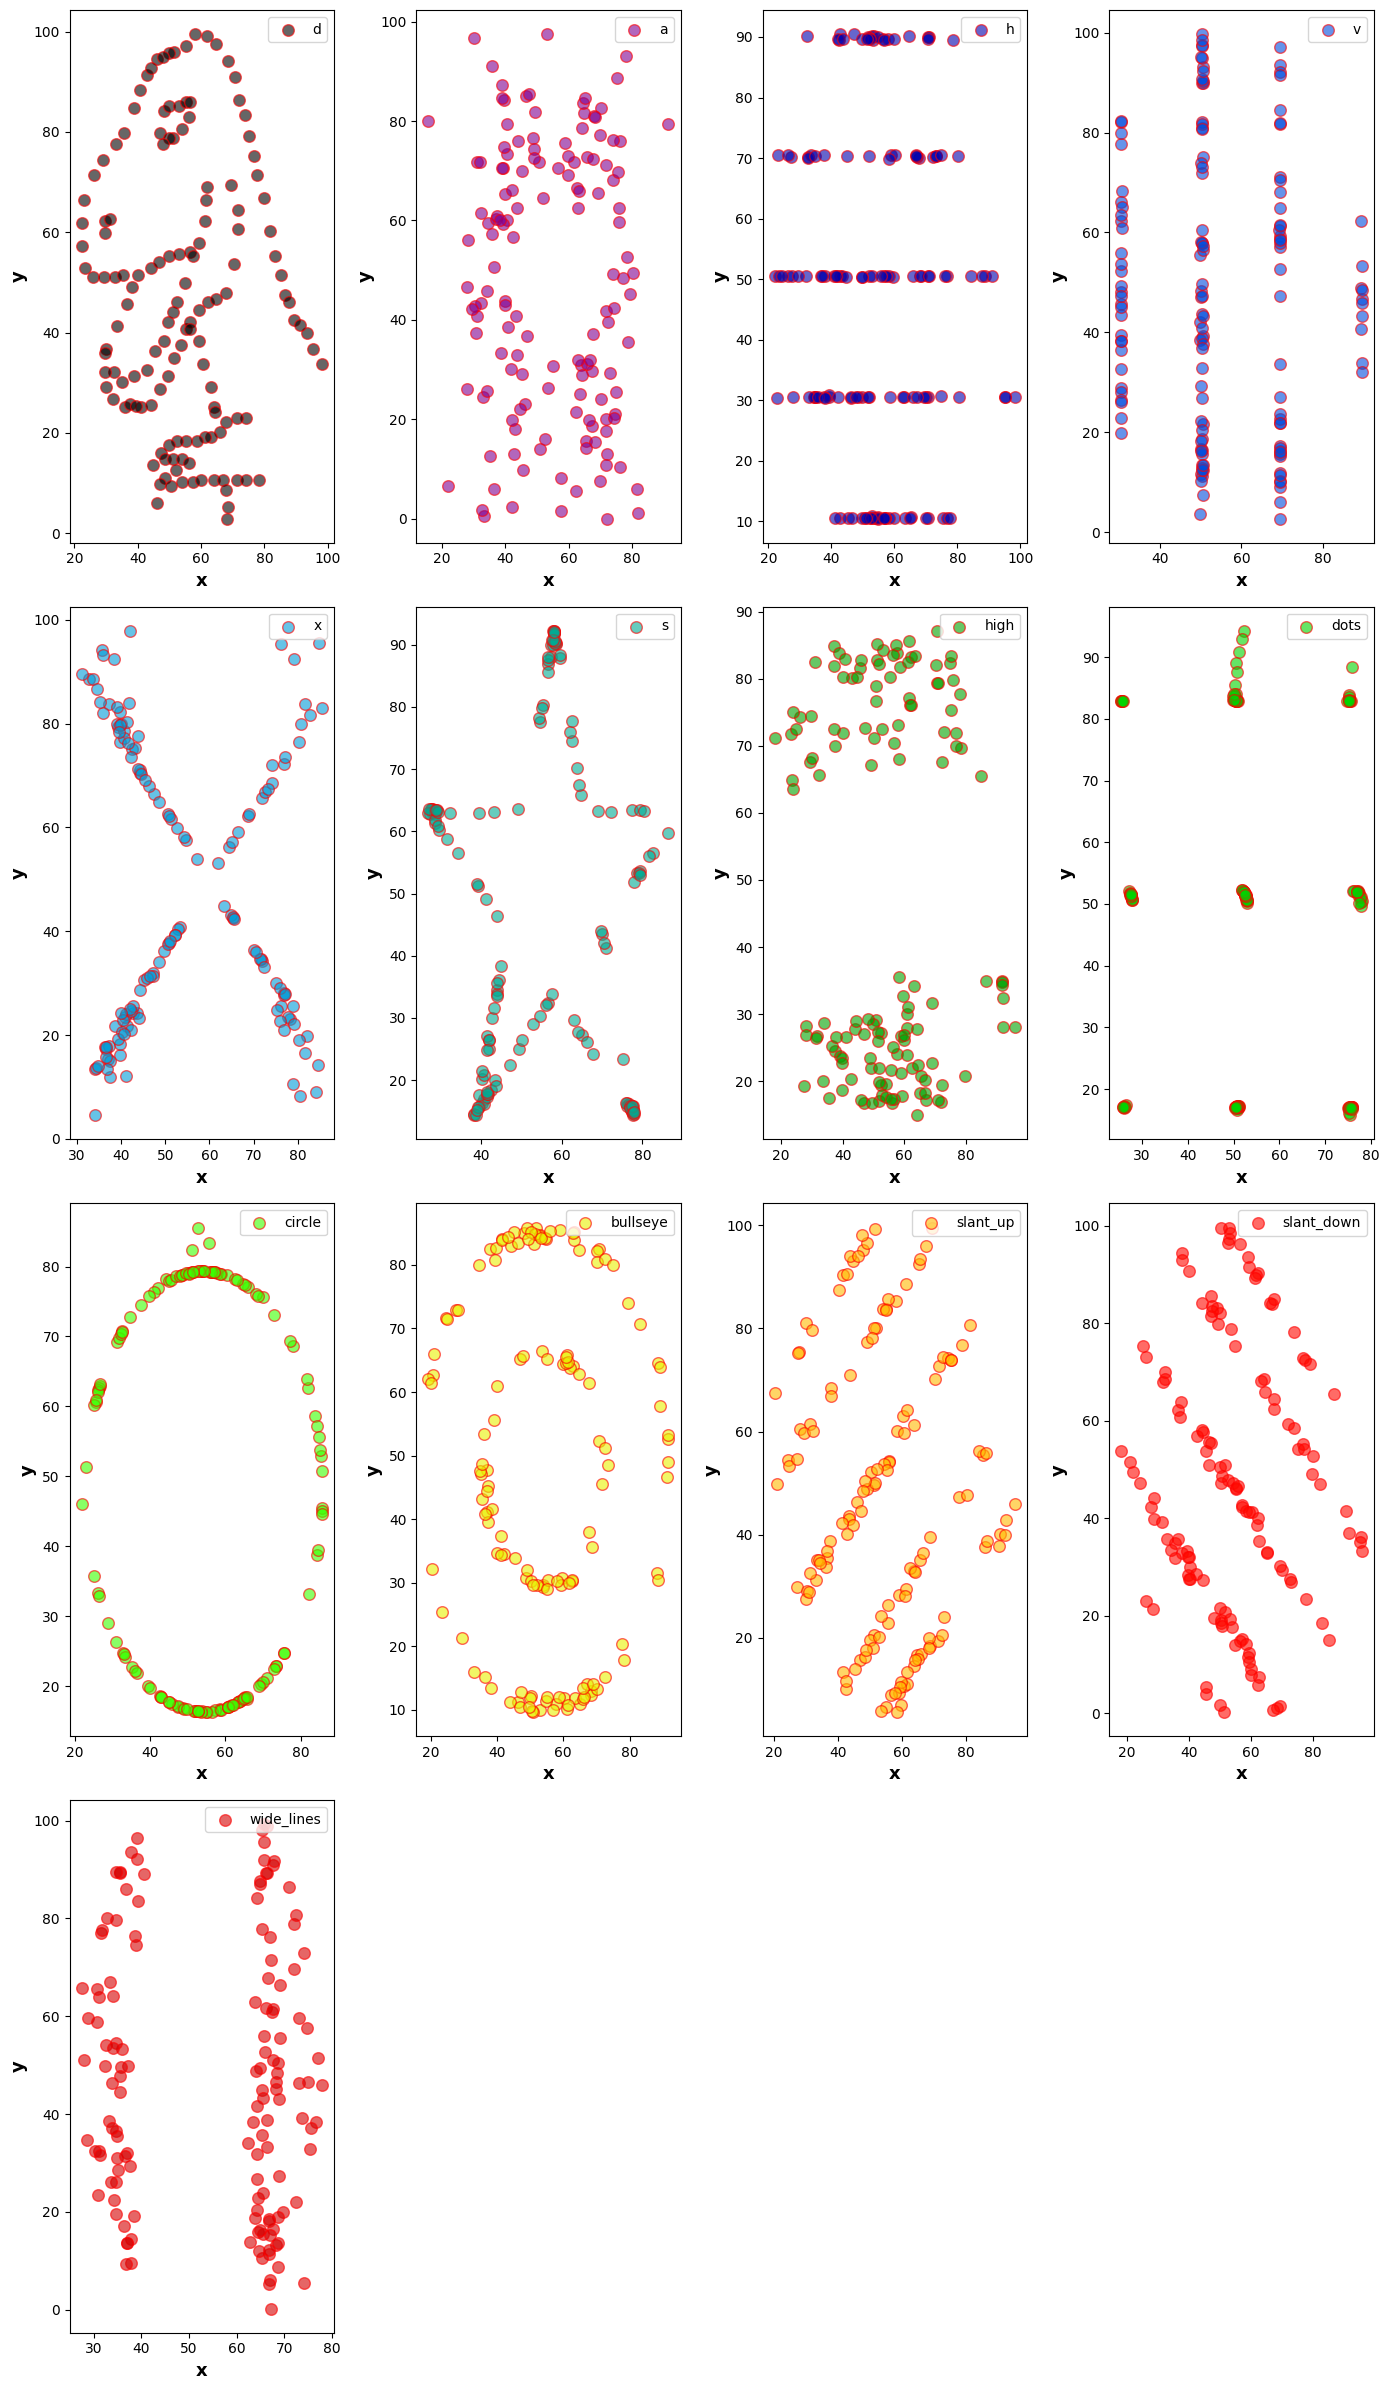

In [ ]:
# Create color map
cmap = plt.get_cmap('nipy_spectral')

ncols = 4  
nrows = (len(datasets) + ncols - 1) // ncols  

# Create figure 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 6*nrows)) 

# Flatten the axs array 
if nrows > 1 or ncols > 1:
    axs = axs.flatten()

# Plot each dataset
for i, dataset in enumerate(datasets):
    ax = axs[i]  # Current axis
    subset = df[df['dataset'] == dataset]
    x = subset['x']
    y = subset['y']

    color = cmap(i / len(datasets))
    
    # Scatter plot
    ax.scatter(x, y, color=color, alpha=0.6, edgecolor='red', s=70)
    
    # Add legend to each plot
    ax.legend([dataset], loc='upper right')
    
    # Subplot labels 
    ax.set_xlabel('x', fontsize=13, fontweight='bold')
    ax.set_ylabel('y', fontsize=13, fontweight='bold')

# Hide empty subplots
for idx in range(len(datasets), nrows * ncols):
    axs[idx].set_visible(False)
    
plt.tight_layout()
plt.show()